In [1]:
# Needed Library Input
import openmc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import os

In [2]:
# Water
water = openmc.Material(name='Water')
water.add_nuclide('H1',  0.666667, 'ao')
water.add_nuclide('O16', 0.333333, 'ao')
water.set_density('g/cm3', 0.99659)

# Graphite
graphite = openmc.Material(name='Graphite')
graphite.add_element('C', 1.0, 'ao')
graphite.set_density('g/cm3', 1.67000)

# Stainless Steel 304
ss304 = openmc.Material(name='SS304')
ss304.add_element('Mn',0.0175,'wo')
ss304.add_element('Cr',0.19,'wo')
ss304.add_element('Fe',0.70,'wo')
ss304.add_element('Ni',0.0925,'wo')
ss304.set_density('g/cm3', 7.82000)

# Aluminum
aluminum = openmc.Material(name='Aluminum')
aluminum.add_nuclide('Al27', 1.0, 'ao')
aluminum.set_density('g/cm3', 2.70700)

# Zirconium
zirconium = openmc.Material(name='Zirconium')
zirconium.add_element('Zr', 1.0)
zirconium.set_density('g/cm3', 6.50000)

# B4C
b4c = openmc.Material(name='B4C')
b4c.add_element('B', 4)
b4c.add_element('C', 1)
b4c.set_density('g/cm3', 2.40000)

# U-ZrH 8.5-20
UZrH = openmc.Material(name='U-ZrH 8.5-20')
UZrH.add_nuclide('U235',   38.0,       'wo')
UZrH.add_nuclide('U238',  154.0,       'wo')
UZrH.add_nuclide('Zr90', 1034.022503,   'wo')
UZrH.add_nuclide('Zr91',  225.4952863,  'wo')
UZrH.add_nuclide('Zr92',  344.6741676,  'wo')
UZrH.add_nuclide('Zr94',  349.29662,    'wo')
UZrH.add_nuclide('Zr96',   56.27333348, 'wo')
UZrH.add_nuclide('H1', 35.5322, 'wo')
UZrH.set_density('g/cm3', 5.79875)

# Materials collection and export to xml
materials = openmc.Materials([water, graphite, ss304, aluminum, zirconium, b4c, UZrH])
materials.export_to_xml()

In [3]:
# Height Boundary
s4   = openmc.ZPlane (z0=   0.000000)                             # Bottom grid plate min
s5   = openmc.ZPlane (z0=   1.905000)                             # Bottom grid plate max
s11  = openmc.ZPlane (z0=  66.992500)                             # Top grid plate min
s12  = openmc.ZPlane (z0=  68.580000)                             # Top grid plate max
s13  = openmc.ZPlane (z0=   6.985000)                             # Fuel end fitting
s14  = openmc.ZPlane (z0=   8.255000)                             # Fuel graphite plug bottom
s15  = openmc.ZPlane (z0=  17.653000)                             # U-ZrH bottom
s16  = openmc.ZPlane (z0=  55.753000)                             # U-ZrH top
s17  = openmc.ZPlane (z0=  62.357000)                             # Fuel graphite plug top
s18  = openmc.ZPlane (z0=  63.627000)                             # Fuel top fitting
s39  = openmc.YPlane (y0=   2.207047, boundary_type='reflective') # Up boundary
s40  = openmc.YPlane (y0=-  2.207047, boundary_type='reflective') # Down boundary
s41  = openmc.Plane  (a= 4.41409, b=-2.54849, c=0, d=-11.24922, boundary_type='reflective')
s42  = openmc.Plane  (a=-4.41409, b=-2.54849, c=0, d= 11.24922, boundary_type='reflective')
s43  = openmc.Plane  (a= 4.41409, b= 2.54849, c=0, d= 11.24922, boundary_type='reflective')
s44  = openmc.Plane  (a=-4.41409, b= 2.54849, c=0, d=-11.24922, boundary_type='reflective')

# Cylinder Boundary
s61  = openmc.ZCylinder (r=  0.93663) # End fitting
s62  = openmc.ZCylinder (r=  0.31750) # Zr rod
s63  = openmc.ZCylinder (r=  1.82245) # U-zrh
s64  = openmc.ZCylinder (r=  1.87325) # Clad
s564 = openmc.ZCylinder (r=  1.91135)
s565 = openmc.ZCylinder (r=  0.35687)

# Cylinder Boundary CR in C-5
s65 =  openmc.ZCylinder (r=  1.55) # B4C
s66 =  openmc.ZCylinder (r=  1.6008) # Clad
# Cylinder Boundary CR in C-9
s67 = openmc.ZCylinder (r=  1.78) # B4C
s68 = openmc.ZCylinder (r=  1.8008) # Clad
#cylinder Boundary CR in E-1
s69 = openmc.ZCylinder (r=  1.4) # B4C
s70 = openmc.ZCylinder (r=  1.4508) # Clad
s71 = openmc.ZCylinder (r=  1.11125) # End fitting
s72 = openmc.ZCylinder (r=  1.19063) # Top fitting
# Reactor Boundary
reactor_wall     = openmc.ZCylinder (r=   58.57875, boundary_type='reflective')
reactor_top      = openmc.ZPlane    (z0= 568.96000, boundary_type='white')
reactor_bottom   = openmc.ZPlane    (z0= -46.35500, boundary_type='white')

In [4]:
# Geometry definitions for the fuel rod

########### Cell Definitions ############

# Bottom end fitting 1
c1  = openmc.Cell (fill   = ss304,
                   region = +s5  & -s13 &  -s61)
# Bottom end fitting 2
c2  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s14 &  -s63))
# Graphite plug bottom
c3  = openmc.Cell (fill   = graphite,
                   region = (+s14 & -s15 &  -s63))
# Zr rod
c4  = openmc.Cell (fill   = zirconium,
                   region = (+s15 & -s16 &  -s62))
# U-ZrH
c5  = openmc.Cell (fill   = UZrH,
                   region = (+s15 & -s16 &  -s63 & +s62))
# Graphite plug top
c6  = openmc.Cell (fill   = graphite,
                   region = (+s16 & -s17 &  -s63))
# Top end fitting 1
c7  = openmc.Cell (fill   = ss304,
                   region = (+s17 & -s18 &  -s63))
# Top end fitting 2
c8  = openmc.Cell (fill   = ss304,
                   region = (+s18 & -s11 &  -s61))
# Clad
c9  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s18 &  -s64 & +s63))
# Top grid 2
c10 = openmc.Cell (fill   = ss304,
                   region = (+s11 & -s12 &  -s61))
# Top grid 3
c11 = openmc.Cell (fill   = aluminum,
                   region = (+s11 & -s12 & +s564 & +s40 & -s39 & +s41 & -s42 & -s43 & +s44))
# Bottom grid 1
c12 = openmc.Cell (fill   = ss304,
                   region = (+s4  &  -s5 & -s565))
# Bottom grid 2
c13 = openmc.Cell (fill   = aluminum,
                   region = (+s4  &  -s5 & +s565 & +s40 & -s39 & +s41 & -s42 & -s43 & +s44))
# Water outside rod
cwater = openmc.Cell (fill   = water)

# Geometry collection
u1_fuel_universe = openmc.Universe(cells= [c1, c2, c3, c4, c5, c6, c7, c8, c9, c10, c11, c12, c13, cwater])


In [5]:
# Geometry definitions for the control rod C-5

# Bottom end fitting 1
c14  = openmc.Cell (fill   = ss304,
                   region = (+s5  & -s13 &  -s71))
# Bottom end fitting 2
c15  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s14 &  -s65))
# Graphite plug bottom
c16  = openmc.Cell (fill   = b4c,
                   region = (+s14 & -s15 &  -s65))
# B4C
c17  = openmc.Cell (fill   = b4c,
                   region = (+s15 & -s16 &  -s65))
# Graphite plug top
c19  = openmc.Cell (fill   = b4c,
                   region = (+s16 & -s17 &  -s65))
# Top end fitting 1
c20  = openmc.Cell (fill   = ss304,
                   region = (+s17 & -s18 &  -s65))
# Top end fitting 2
c21  = openmc.Cell (fill   = ss304,
                   region = (+s18 & -s11 &  -s72))
# Clad
c22  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s18 &  -s66 & +s65))
# Water outside rod
cwater2= openmc.Cell (fill = water)

# Geometry collection
u2_control_universe = openmc.Universe(cells= [c14, c15, c16, c17, c19, c20, c21, c22, cwater2])

# Geometry grid control rod fixed
c23_fixed = openmc.Cell (fill=ss304,    
                         region=(+s11 & -s12 & -s71))
c24_fixed = openmc.Cell (fill=aluminum, 
                         region=(+s11 & -s12 & +s564 & +s40 & -s39 & +s41 & -s42 & -s43 & +s44))
c25_fixed = openmc.Cell (fill=ss304,    
                         region=(+s4  & -s5  & -s565))
c26_fixed = openmc.Cell (fill=aluminum, 
                         region=(+s4  & -s5  & +s565 & +s40 & -s39 & +s41 & -s42 & -s43 & +s44))
cwater_grid = openmc.Cell (fill=water)

u2_grid_universe = openmc.Universe(cells=[c23_fixed, c24_fixed, c25_fixed, c26_fixed, cwater_grid])

In [6]:
# Geometry definitions for the control rod C-9

# Bottom end fitting 1
c40  = openmc.Cell (fill   = ss304,
                   region = (+s5  & -s13 &  -s71))
# Bottom end fitting 2
c41  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s14 &  -s67))
# Graphite plug bottom
c42  = openmc.Cell (fill   = b4c,
                   region = (+s14 & -s15 &  -s67))
# B4C
c43  = openmc.Cell (fill   = b4c,
                   region = (+s15 & -s16 &  -s67))
# Graphite plug top
c44  = openmc.Cell (fill   = b4c,
                   region = (+s16 & -s17 &  -s67))
# Top end fitting 1
c45  = openmc.Cell (fill   = ss304,
                   region = (+s17 & -s18 &  -s67))
# Top end fitting 2
c46  = openmc.Cell (fill   = ss304,
                   region = (+s18 & -s11 &  -s72))
# Clad
c47  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s18 &  -s68 & +s67))
# Water outside rod
cwater3= openmc.Cell (fill = water)

# Geometry collection
u3_control_universe = openmc.Universe(cells= [c40, c41, c42, c43, c44, c45, c46, c47, cwater3])


In [7]:
# Geometry definitions for the control rod E-1

# Bottom end fitting 1
c48  = openmc.Cell (fill   = ss304,
                   region = (+s5  & -s13 &  -s71))
# Bottom end fitting 2
c49  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s14 &  -s69))
# Graphite plug bottom
c50  = openmc.Cell (fill   = b4c,
                   region = (+s14 & -s15 &  -s69))
# B4C
c51  = openmc.Cell (fill   = b4c,
                   region = (+s15 & -s16 &  -s69))
# Graphite plug top
c52  = openmc.Cell (fill   = b4c,
                   region = (+s16 & -s17 &  -s69))
# Top end fitting 1
c53  = openmc.Cell (fill   = ss304,
                   region = (+s17 & -s18 &  -s69))
# Top end fitting 2
c54  = openmc.Cell (fill   = ss304,
                   region = (+s18 & -s11 &  -s72))
# Clad
c55  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s18 &  -s70 & +s69))
# Water outside rod
cwater4= openmc.Cell (fill = water)

# Geometry collection
u4_control_universe = openmc.Universe(cells= [c48, c49, c50, c51, c52, c53, c54, c55, cwater4])

In [8]:
# Geometry definitions for the dummy rod
c27  = openmc.Cell (fill   = ss304,
                   region = (+s5  & -s13 &  -s61))
# Bottom end fitting 2
c28  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s14 &  -s63))
# Graphite plug bottom
c29  = openmc.Cell (fill   = graphite,
                   region = (+s14 & -s15 &  -s63))
# Zr rod
c30  = openmc.Cell (fill   = graphite,
                   region = (+s15 & -s16 &  -s62))
# U-ZrH
c31  = openmc.Cell (fill   = graphite,
                   region = (+s15 & -s16 &  -s63 & +s62))
# Graphite plug top
c32  = openmc.Cell (fill   = graphite,
                   region = (+s16 & -s17 &  -s63))
# Top end fitting 1
c33  = openmc.Cell (fill   = ss304,
                   region = (+s17 & -s18 &  -s63))
# Top end fitting 2
c34  = openmc.Cell (fill   = ss304,
                   region = (+s18 & -s11 &  -s61))
# Clad
c35  = openmc.Cell (fill   = ss304,
                   region = (+s13 & -s18 &  -s64 & +s63))
# Top grid 2
c36 = openmc.Cell (fill   = ss304,
                   region = (+s11 & -s12 &  -s61))
# Top grid 3
c37 = openmc.Cell (fill   = aluminum,
                   region = (+s11 & -s12 & +s564 & +s40 & -s39 & +s41 & -s42 & -s43 & +s44))
# Bottom grid 1
c38 = openmc.Cell (fill   = ss304,
                   region = (+s4  &  -s5 & -s565))
# Bottom grid 2
c39 = openmc.Cell (fill   = aluminum,
                   region = (+s4  &  -s5 & +s565 & +s40 & -s39 & +s41 & -s42 & -s43 & +s44))
# Water outside rod
cwater5 = openmc.Cell (fill = water)

# Geometry collection
u5_dummy_universe = openmc.Universe(cells= [c27, c28, c29, c30, c31, c32, c33, c34, c35, c36, c37, c38, c39, cwater5])

In [9]:
# Geometry definitions for the empty rod

# Water
cwater6= openmc.Cell (fill = water)

# Geometry collection
u6_empty_universe = openmc.Universe(cells= [cwater6])

# Create water universe to surround the lattice

all_water_cell = openmc.Cell(fill=water)
outer_universe = openmc.Universe(cells=(all_water_cell,))

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

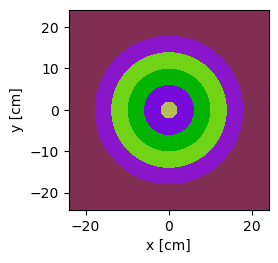

In [10]:
# Create surfaces that will divide rings in the circular lattice

ring_radii = np.array([0, 4.05130, 7.98068, 11.94562, 15.91564, 19.88820])
radial_surf = [openmc.ZCylinder(r=r) for r in
               (ring_radii[:-1] + ring_radii[1:])/2]

water_cells = []
for i in range(ring_radii.size):
    # Create annular region
    if i == 0:
        water_region = -radial_surf[i]
    elif i == ring_radii.size - 1:
        water_region = +radial_surf[i-1]
    else:
        water_region = +radial_surf[i-1] & -radial_surf[i]
    water_cells.append(openmc.Cell(fill=water, region=water_region))

# Plot the rings to visualize the circular lattice, without rods

plot_args = {'width': (2*24.1, 2*24.1)}
bundle_universe = openmc.Universe(cells=water_cells)
bundle_universe.plot(**plot_args)

In [11]:
num_pins = [1, 6, 12, 18, 24, 30]
angles   = [0, 0, 0, 0, 0, 0]

controlRod_C5 = {'numPins': num_pins[2], 'howLeftFrom3oclock': 10,
                 'universe': u2_control_universe, 'clad_r': s66.r}
controlRod_C9 = {'numPins': num_pins[2], 'howLeftFrom3oclock':  6,
                 'universe': u3_control_universe, 'clad_r': s68.r}
controlRod_E1 = {'numPins': num_pins[4], 'howLeftFrom3oclock':  5,
                 'universe': u4_control_universe, 'clad_r': s70.r}

ALL_CONTROL_RODS = [controlRod_C5, controlRod_C9, controlRod_E1]

DummyRods = {'numPins':            [num_pins[5]]*14,
             'howLeftFrom3oclock': [0,1,3,9,10,11,13,15,18,21,22,23,25,28]}
emptyRods = {'numPins':            [num_pins[0]],
             'howLeftFrom3oclock': [-1]}

def GetControlRodInfo(n, j):
    for rod in ALL_CONTROL_RODS:
        if n == rod['numPins'] and j-1 == rod['howLeftFrom3oclock']:
            return rod
    return None

def DummyRod(n, j):
    for k in range(len(DummyRods['numPins'])):
        if n == DummyRods['numPins'][k] and j-1 == DummyRods['howLeftFrom3oclock'][k]:
            return True
    return False

def EmptyRod(n, j):
    for k in range(len(emptyRods['numPins'])):
        if n == emptyRods['numPins'][k] and j-1 == emptyRods['howLeftFrom3oclock'][k]:
            return True
    return False

rod_name_map = {u2_control_universe: 'C-5',
                u3_control_universe: 'C-9',
                u4_control_universe: 'E-1'}

for i, (r, n, a) in enumerate(zip(ring_radii, num_pins, angles)):
    for j in range(n):
        theta = (a + j/n*360.) * np.pi/180.
        x = r * np.cos(theta)
        y = r * np.sin(theta)

        cr_info = GetControlRodInfo(n, j)

        if cr_info is not None:
            pin_boundary = openmc.ZCylinder(x0=x, y0=y, r=cr_info['clad_r'])
            water_cells[i].region &= +pin_boundary

            name = rod_name_map[cr_info['universe']]
            print(f'Adding control rod {name} '
                  f'(pin_r={cr_info["clad_r"]:.4f}) at ring {i}, pos {j}')

            pin = openmc.Cell(fill=cr_info['universe'], region=-pin_boundary)
            pin.translation = (x, y, 0)
            bundle_universe.add_cell(pin)

            pin_grid = openmc.Cell(fill=u2_grid_universe, region=-pin_boundary)
            pin_grid.translation = (x, y, 0)
            bundle_universe.add_cell(pin_grid)
            continue

        else:
            pin_boundary = openmc.ZCylinder(x0=x, y0=y, r=s64.r)
            water_cells[i].region &= +pin_boundary

            if DummyRod(n, j):
                print(f'Adding dummy rod at ring {i}, pos {j}')
                pin = openmc.Cell(fill=u5_dummy_universe, region=-pin_boundary)
            elif EmptyRod(n, j):
                print(f'Adding empty rod at ring {i}, pos {j}')
                pin = openmc.Cell(fill=u6_empty_universe, region=-pin_boundary)
            else:
                pin = openmc.Cell(fill=u1_fuel_universe, region=-pin_boundary)

        pin.translation = (x, y, 0)
        bundle_universe.add_cell(pin)

Adding empty rod at ring 0, pos 0
Adding control rod C-9 (pin_r=1.8008) at ring 2, pos 7
Adding control rod C-5 (pin_r=1.6008) at ring 2, pos 11
Adding control rod E-1 (pin_r=1.4508) at ring 4, pos 6
Adding dummy rod at ring 5, pos 1
Adding dummy rod at ring 5, pos 2
Adding dummy rod at ring 5, pos 4
Adding dummy rod at ring 5, pos 10
Adding dummy rod at ring 5, pos 11
Adding dummy rod at ring 5, pos 12
Adding dummy rod at ring 5, pos 14
Adding dummy rod at ring 5, pos 16
Adding dummy rod at ring 5, pos 19
Adding dummy rod at ring 5, pos 22
Adding dummy rod at ring 5, pos 23
Adding dummy rod at ring 5, pos 24
Adding dummy rod at ring 5, pos 26
Adding dummy rod at ring 5, pos 29


<Axes: xlabel='x [cm]', ylabel='y [cm]'>

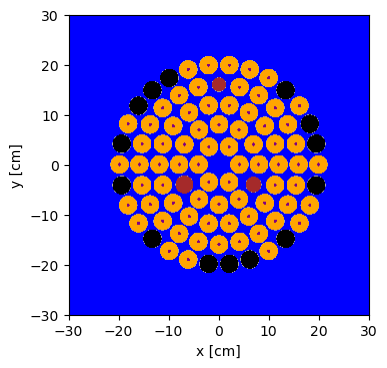

In [12]:
# Plot the rings to visualize the filled circular lattice

bundle_universe.plot(origin   = (0,0,20),
   	                 pixels	  = (300, 300),
                     width    = (60,60), 
                     basis 	  = 'xy', 
                     color_by = 'material', 
                     colors   = {water:'blue', graphite:'black',
                                 ss304:'darkgrey', aluminum:'lightgray',
                                 zirconium:'purple', b4c:'brown',
                                 UZrH:"orange"})

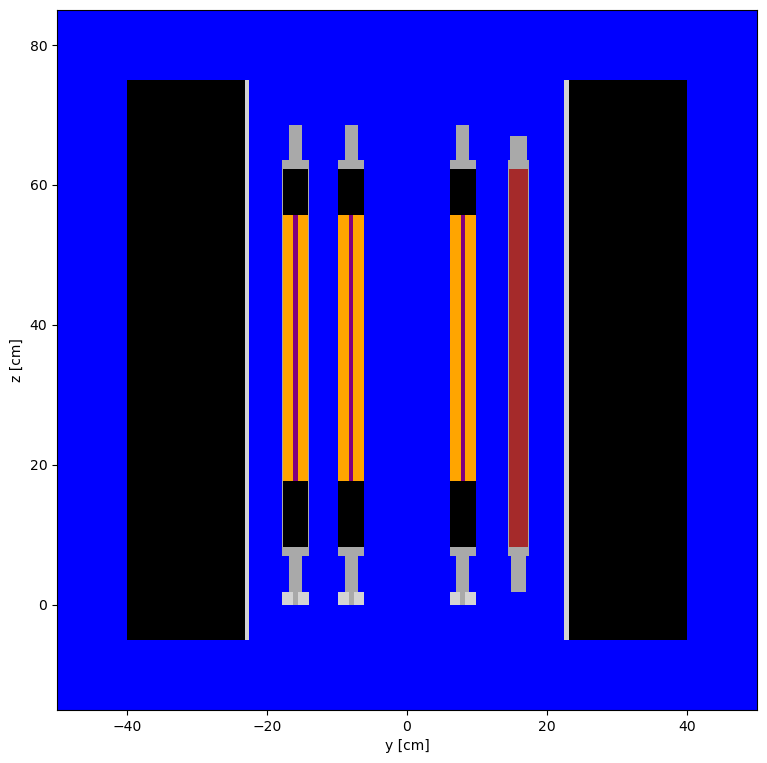

In [15]:
refl_inner  = openmc.ZCylinder(r=23.2)
refl_outer  = openmc.ZCylinder(r=40.0)
tank_inner  = openmc.ZCylinder(r=22.5)
tank_outer  = openmc.ZCylinder(r=23.2) 
core_bound  = openmc.ZCylinder(r=22.0)
refl_bottom = openmc.ZPlane(z0= -5.0)   
refl_top    = openmc.ZPlane(z0= 75.0)   

# Water gap between core and tank wall 
water_gap_cell = openmc.Cell (fill   = water,
                              region = +core_bound & -tank_inner & +refl_bottom & -refl_top)
# Aluminum tank wall
tank_wall_cell = openmc.Cell (fill   = aluminum,
                              region = +tank_inner & -tank_outer & +refl_bottom & -refl_top)
# Graphite reflector
graphite_reflector = openmc.Cell (fill   = graphite,
                                  region = +refl_inner & -refl_outer & +refl_bottom & -refl_top)
outer_water        = openmc.Cell (fill   = water,
                                  region = +refl_outer & -reactor_wall & +reactor_bottom & -reactor_top)
water_above_refl   = openmc.Cell (fill   = water,
                                  region = +refl_inner & -refl_outer & +refl_top & -reactor_top)
water_below_refl   = openmc.Cell (fill   = water,
                                  region = +refl_inner & -refl_outer & +reactor_bottom & -refl_bottom)
water_gap_above    = openmc.Cell (fill   = water,
                                  region = +core_bound & -refl_inner & +refl_top & -reactor_top)
water_gap_below    = openmc.Cell (fill   = water,
                                  region = +core_bound & -refl_inner & +reactor_bottom & -refl_bottom)
core_cell          = openmc.Cell (fill   = bundle_universe,
                                  region = -core_bound & +reactor_bottom & -reactor_top)
reactor_universe = openmc.Universe(cells=[core_cell, 
                                          water_gap_cell, 
                                          tank_wall_cell, 
                                          graphite_reflector, 
                                          water_above_refl, 
                                          water_below_refl,
                                          water_gap_above,
                                          water_gap_below,
                                          outer_water])

reactor_universe.plot(origin   = (0,0,35), 
                      pixels   = (700, 700),
                      width    = (100, 100),
                      basis    ='yz',
                      color_by ='material',
                      colors   = {water:'blue', graphite:'black',
                                  ss304:'darkgrey', aluminum:'lightgrey',
                                  zirconium:'purple', b4c:'brown',
                                  UZrH:"orange"})

geometry = openmc.Geometry(reactor_universe)
geometry.export_to_xml()

In [14]:
fuel_length = s16.z0 - s15.z0  # 38.1 cm

withdrawal = {u3_control_universe: 0.00 * fuel_length,   # C-9  60%
              u2_control_universe: 0.00 * fuel_length,   # C-5  100%
             }
variable_universe   = u4_control_universe
withdrawal_fraction = 0.0
variable_withdrawal = withdrawal_fraction * fuel_length

rod_names = {u2_control_universe: 'C-5 (safety)',
             u3_control_universe: 'C-9 (kompensasi)',
             u4_control_universe: 'E-1 (regulating)'}

print("Applying withdrawal:")
for cell in bundle_universe.cells.values():
    if cell.fill not in (u2_control_universe,
                         u3_control_universe,
                         u4_control_universe):
        continue
    x, y, _ = cell.translation
    shift = variable_withdrawal if cell.fill is variable_universe \
            else withdrawal[cell.fill]
    cell.translation = (x, y, shift)
    name = rod_names[cell.fill]
    print(f"  {name} at ({x:.3f}, {y:.3f}) "
          f"→ {shift:.2f} cm ({shift/fuel_length*100:.0f}%)")

Applying withdrawal:
  C-9 (kompensasi) at (-6.911, -3.990) → 0.00 cm (0%)
  C-5 (safety) at (6.911, -3.990) → 0.00 cm (0%)
  E-1 (regulating) at (0.000, 15.916) → 0.00 cm (0%)


In [42]:
# Tallies 
tallies = openmc.Tallies()

fission_by_mat = openmc.Tally(name='fission_by_material')
fission_by_mat.filters = [openmc.MaterialFilter([UZrH])]
fission_by_mat.scores  = ['fission', 'kappa-fission']
tallies.append(fission_by_mat)

# axial power distribution 
z_mesh = openmc.RegularMesh()
z_mesh.dimension   = [1, 1, 50]
z_mesh.lower_left  = [-25.0, -25.0, s15.z0]
z_mesh.upper_right = [ 25.0,  25.0, s16.z0]

axial_tally = openmc.Tally(name='axial_power')
axial_tally.filters = [openmc.MeshFilter(z_mesh)]
axial_tally.scores  = ['kappa-fission']
tallies.append(axial_tally)

# radial power distribution 
xy_mesh = openmc.RegularMesh()
xy_mesh.dimension   = [50, 50, 1]
xy_mesh.lower_left  = [-22.0, -22.0, 35.0]
xy_mesh.upper_right = [ 22.0,  22.0, 37.0]

radial_tally = openmc.Tally(name='radial_power')
radial_tally.filters = [openmc.MeshFilter(xy_mesh)]
radial_tally.scores  = ['kappa-fission']
tallies.append(radial_tally)

tallies.export_to_xml()

settings = openmc.Settings()
settings.particles             = 10000
settings.generations_per_batch = 1
settings.inactive              = 50
settings.batches               = 150
settings.survival_biasing      = False
settings.source = openmc.IndependentSource(
    space=openmc.stats.Point((0, 0, 35))
)
settings.export_to_xml()

openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

  KARTINI REACTOR — POWER CONVERSION RESULTS

  Control rod configuration:
    C-5 (safety)              0% withdrawn
    C-9 (shim/comp)           0% withdrawn
    E-1 (regulating)          0% withdrawn

  k-eff                  = 0.98664 ± 0.00105
  Reactivity (ρ)         = -1354.5 pcm

  ── Power ──────────────────────────────────────────
  Target power           = 100.0 kW
  Normalization factor   = 7.9457e+15 n/s
  J per fission          = 3.2476e-11 J
  Fissions/second        = 3.2269e+15 fiss/s

  ── Axial power analysis ───────────────────────────
  Total axial power      = 100.000 kW (sum of 50 slices)
  Average power/slice    = 2.0000 kW
  Peak power (slice 25)  = 2.4781 kW
  Axial peaking factor   = 1.239
  Peak power position    = z = 36.3 cm


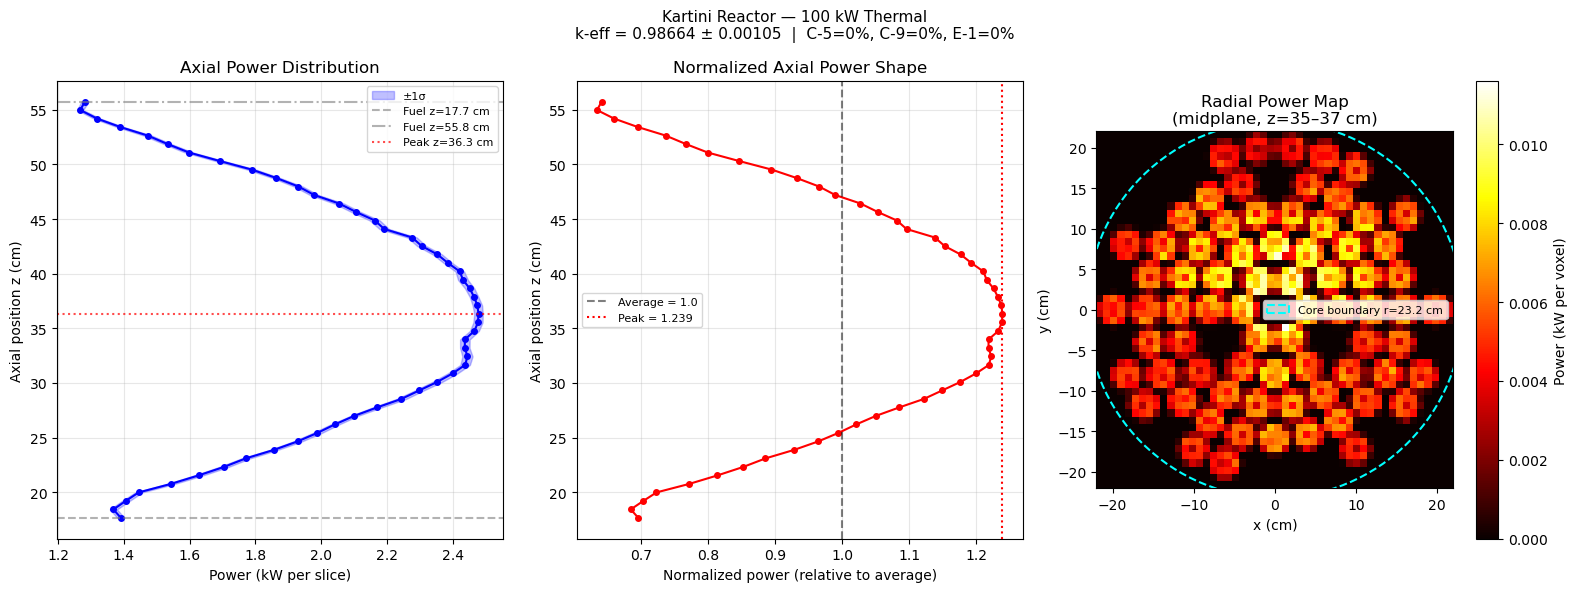


Saved: kartini_power_100kW.png


In [17]:
# Load statepoint 
sp      = openmc.StatePoint('statepoint.150.h5')
k       = sp.keff.nominal_value
sigma_k = sp.keff.std_dev

# Constants 
J_per_eV       = 1.602176634e-19
target_power_W = 100e3   # 100 kW

# Control rod configuration used in this run 
fuel_length = s16.z0 - s15.z0
rod_config  = {
    'C-5 (safety)':       0.00,
    'C-9 (shim/comp)':    0.00,
    'E-1 (regulating)':   0.00,
}

# Read kappa-fission tally for normalization 
mat_tally = sp.get_tally(name='fission_by_material')
kappa_val  = mat_tally.get_values(scores=['kappa-fission']).flatten()[0]
kappa_unc  = mat_tally.get_values(scores=['kappa-fission'],
                                   value='std_dev').flatten()[0]

# Normalization factor: scales OpenMC source neutrons to real reactor power
# Power (W) = kappa_val (eV/source_n) × J_per_eV × norm_factor (source_n/s)
norm_factor    = target_power_W / (kappa_val * J_per_eV)
norm_factor_unc = norm_factor * (kappa_unc / kappa_val)

# Derived power quantities 
eV_per_fission = 202.7e6
J_per_fission  = eV_per_fission * J_per_eV

fission_tally  = mat_tally.get_values(scores=['fission']).flatten()[0]
fissions_per_sec = fission_tally * norm_factor

# Axial power distribution 
axial_tally  = sp.get_tally(name='axial_power')
axial_vals   = axial_tally.get_values(scores=['kappa-fission']).flatten()
axial_unc    = axial_tally.get_values(scores=['kappa-fission'],
                                       value='std_dev').flatten()

axial_power_W   = axial_vals * norm_factor * J_per_eV
axial_power_unc = axial_unc  * norm_factor * J_per_eV
z_centers = np.linspace(s15.z0, s16.z0, len(axial_power_W))

peak_idx          = axial_power_W.argmax()
peak_power_W      = axial_power_W[peak_idx]
axial_peak_factor = axial_power_W.max() / axial_power_W.mean()

# Radial power distribution 
radial_tally = sp.get_tally(name='radial_power')
radial_vals  = radial_tally.get_values(scores=['kappa-fission']).reshape(50, 50)
radial_power = radial_vals * norm_factor * J_per_eV

# Print results
print("=" * 60)
print("  KARTINI REACTOR — POWER CONVERSION RESULTS")
print("=" * 60)
print(f"\n  Control rod configuration:")
for rod, frac in rod_config.items():
    print(f"    {rod:<25} {frac*100:.0f}% withdrawn")

print(f"\n  k-eff                  = {k:.5f} ± {sigma_k:.5f}")
reactivity_pcm = (k - 1) / k * 1e5
print(f"  Reactivity (ρ)         = {reactivity_pcm:.1f} pcm")

print(f"\n Power")
print(f"  Target power           = {target_power_W/1e3:.1f} kW")
print(f"  Normalization factor   = {norm_factor:.4e} n/s")
print(f"  J per fission          = {J_per_fission:.4e} J")
print(f"  Fissions/second        = {fissions_per_sec:.4e} fiss/s")

print(f"\n Axial power analysis")
print(f"  Total axial power      = {axial_power_W.sum()/1e3:.3f} kW "
      f"(sum of {len(axial_power_W)} slices)")
print(f"  Average power/slice    = {axial_power_W.mean()/1e3:.4f} kW")
print(f"  Peak power (slice {peak_idx+1:2d})  = {peak_power_W/1e3:.4f} kW")
print(f"  Axial peaking factor   = {axial_peak_factor:.3f}")
print(f"  Peak power position    = z = {z_centers[peak_idx]:.1f} cm")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot 1: Axial power distribution
ax = axes[0]
ax.plot(axial_power_W / 1e3, z_centers, 'b-o', markersize=4, linewidth=1.5)
ax.fill_betweenx(z_centers,
                  (axial_power_W - axial_power_unc) / 1e3,
                  (axial_power_W + axial_power_unc) / 1e3,
                  alpha=0.25, color='blue', label='±1σ')
ax.axhline(s15.z0, color='gray', linestyle='--', alpha=0.6,
           label=f'Fuel z={s15.z0:.1f} cm')
ax.axhline(s16.z0, color='gray', linestyle='-.', alpha=0.6,
           label=f'Fuel z={s16.z0:.1f} cm')
ax.axhline(z_centers[peak_idx], color='red', linestyle=':',
           alpha=0.7, label=f'Peak z={z_centers[peak_idx]:.1f} cm')
ax.set_xlabel('Power (kW per slice)')
ax.set_ylabel('Axial position z (cm)')
ax.set_title('Axial Power Distribution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Normalized axial power shape
ax = axes[1]
norm_shape = axial_power_W / axial_power_W.mean()
ax.plot(norm_shape, z_centers, 'r-o', markersize=4, linewidth=1.5)
ax.axvline(1.0, color='black', linestyle='--', alpha=0.5,
           label='Average = 1.0')
ax.axvline(axial_peak_factor, color='red', linestyle=':',
           label=f'Peak = {axial_peak_factor:.3f}')
ax.set_xlabel('Normalized power (relative to average)')
ax.set_ylabel('Axial position z (cm)')
ax.set_title('Normalized Axial Power Shape')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Radial power map (top-down at midplane)
ax = axes[2]
im = ax.imshow(radial_power / 1e3,
               extent=[-22, 22, -22, 22],
               origin='lower',
               cmap='hot',
               aspect='equal')
plt.colorbar(im, ax=ax, label='Power (kW per voxel)')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_title('Radial Power Map\n(midplane, z=35–37 cm)')
ax.add_patch(plt.Circle((0, 0), refl_inner.r,
                          fill=False, color='cyan',
                          linewidth=1.5, linestyle='--',
                          label=f'Core boundary r={refl_inner.r} cm'))
ax.legend(fontsize=8)

plt.suptitle(
    f'Kartini Reactor — {target_power_W/1e3:.0f} kW Thermal\n'
    f'k-eff = {k:.5f} ± {sigma_k:.5f}  |  '
    f'C-5=0%, C-9=0%, E-1=0%',
    fontsize=11
)
plt.tight_layout()
plt.savefig('kartini_power_100kW.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: kartini_power_100kW.png")

In [44]:
# k-eff values 
k_ref  = 1.02673   # reference critical state
sp_curr   = openmc.StatePoint('statepoint.150.h5')
k_curr = sp_curr.keff.nominal_value
sigma_k = sp_curr.keff.std_dev

# Beta effective 
# For TRIGA U-ZrH fuel, β_eff ≈ 0.0070 (700 pcm) is the standard value
# If you have computed β_eff from IFP, replace this with your actual value
beta_eff       = 0.0069   # dimensionless (700 pcm)
beta_eff_pcm   = beta_eff * 1e5

# Reactivity of current state relative to reference 
# Δρ = ρ_curr - ρ_ref (excess reactivity above critical)
rho_ref  = (k_ref  - 1) / k_ref
rho_curr = (k_curr - 1) / k_curr
delta_rho = rho_curr - rho_ref   # excess reactivity

# Uncertainty propagation: σ_ρ = σ_k / k²
sigma_rho_curr  = sigma_k / k_curr**2
sigma_delta_rho = sigma_rho_curr   # ref is fixed, no uncertainty

# Convert to dollars and cents 
# 1 dollar = β_eff,  1 cent = β_eff / 100
dollars     = delta_rho / beta_eff
cents       = dollars * 100
sigma_dollars = sigma_delta_rho / beta_eff
sigma_cents   = sigma_dollars * 100

# Also compute absolute reactivity (not relative to reference)
dollars_abs    = rho_curr / beta_eff
cents_abs      = dollars_abs * 100
sigma_dol_abs  = sigma_rho_curr / beta_eff
sigma_cent_abs = sigma_dol_abs * 100

# Print results 
print("=" * 55)
print("  REACTIVITY UNIT CONVERSION")
print("=" * 55)
print(f"\n  β_eff assumed        = {beta_eff:.4f} ({beta_eff_pcm:.0f} pcm)")

print(f"\n  ── Absolute reactivity (relative to k=1) ────────")
print(f"  k-eff                = {k_curr:.5f} ± {sigma_k:.5f}")
print(f"  ρ (Δk/k)             = {rho_curr:.6f} ± {sigma_rho_curr:.6f}")
print(f"  ρ (pcm)              = {rho_curr*1e5:.2f} ± {sigma_rho_curr*1e5:.2f} pcm")
print(f"  ρ (dollars)          = {dollars_abs:.4f} ± {sigma_dol_abs:.4f} $")
print(f"  ρ (cents)            = {cents_abs:.2f} ± {sigma_cent_abs:.2f} ¢")

print(f"\n  ── Excess reactivity (relative to critical state) ─")
print(f"  k_ref                = {k_ref:.5f} (reference critical)")
print(f"  Δρ (Δk/k)            = {delta_rho:.6f} ± {sigma_delta_rho:.6f}")
print(f"  Δρ (pcm)             = {delta_rho*1e5:.2f} ± {sigma_delta_rho*1e5:.2f} pcm")
print(f"  Δρ (dollars)         = {dollars:.4f} ± {sigma_dollars:.4f} $")
print(f"  Δρ (cents)           = {cents:.2f} ± {sigma_cents:.2f} ¢")

# Interpretation 
print(f"\n Interpretation")
if rho_curr > 0:
    state = "SUPERCRITICAL"
    sign  = "+"
elif rho_curr < 0:
    state = "SUBCRITICAL"
    sign  = ""
else:
    state = "CRITICAL"
    sign  = ""

print(f"  Reactor state        = {state}")
print(f"  Reactivity           = {sign}{cents_abs:.2f} ¢ = {sign}{dollars_abs:.4f} $")

if abs(dollars_abs) < 1.0:
    print(f"  Safe range           = ✓ below 1 dollar (prompt critical threshold)")
else:
    print(f"  WARNING              = ✗ above 1 dollar — prompt critical risk!")

# Unit reference table 
print(f"\n Unit reference")
print(f"  {'Unit':<12} {'Definition':<20} {'This run':>15}")
print(f"  {'─'*12} {'─'*20} {'─'*15}")
print(f"  {'1 dollar':<12} {'ρ = β_eff':<20} {beta_eff:.4f} Δk/k")
print(f"  {'1 cent':<12} {'ρ = β_eff/100':<20} {beta_eff/100:.6f} Δk/k")
print(f"  {'1 pcm':<12} {'ρ = 1×10⁻⁵':<20} {'1×10⁻⁵ Δk/k':>15}")
print(f"\n  β_eff = {beta_eff:.4f} → 1$ = {beta_eff*1e5:.0f} pcm = {beta_eff:.4f} Δk/k")

  REACTIVITY UNIT CONVERSION

  β_eff assumed        = 0.0069 (690 pcm)

  ── Absolute reactivity (relative to k=1) ────────
  k-eff                = 1.04366 ± 0.00087
  ρ (Δk/k)             = 0.041834 ± 0.000795
  ρ (pcm)              = 4183.42 ± 79.53 pcm
  ρ (dollars)          = 6.0629 ± 0.1153 $
  ρ (cents)            = 606.29 ± 11.53 ¢

  ── Excess reactivity (relative to critical state) ─
  k_ref                = 1.02673 (reference critical)
  Δρ (Δk/k)            = 0.015800 ± 0.000795
  Δρ (pcm)             = 1580.01 ± 79.53 pcm
  Δρ (dollars)         = 2.2899 ± 0.1153 $
  Δρ (cents)           = 228.99 ± 11.53 ¢

 Interpretation
  Reactor state        = SUPERCRITICAL
  Reactivity           = +606.29 ¢ = +6.0629 $
  WARNING              = ✗ above 1 dollar — prompt critical risk!

 Unit reference
  Unit         Definition                  This run
  ──────────── ──────────────────── ───────────────
  1 dollar     ρ = β_eff            0.0069 Δk/k
  1 cent       ρ = β_eff/100       